# Tesla Deliveries & Production Data Analysis

## End-to-End Machine Learning Pipeline

### Project Objective

This project develops a complete machine learning pipeline using Tesla deliveries and production data. The workflow includes:

- Data preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Regression modeling
- Hyperparameter tuning
- Time series forecasting

**Tools Used**

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Statsmodels

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")
print("Libraries imported successfully!")


Libraries imported successfully!


# Load the Dataset


In [2]:
df = pd.read_csv("../data/tesla_deliveries_dataset_2015_2025.csv")


df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (2640, 12)


In [4]:
print(df.columns.tolist())

['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB


In [6]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


# Data Preprocessing


In [7]:
# Check for duplicate rows
duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [8]:
# Remove duplicate rows if present
df = df.drop_duplicates()

print("Dataset Shape after removing duplicates:", df.shape)

Dataset Shape after removing duplicates: (2640, 12)


In [9]:
# Check missing values
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [10]:
# Numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(list(numerical_cols))

print("\nCategorical Columns:")
print(list(categorical_cols))

Numerical Columns:
['Year', 'Month', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

Categorical Columns:
['Region', 'Model', 'Source_Type']


# Exploratory Data Analysis (EDA)

In this section, we analyze the dataset to understand distributions, relationships between variables, and trends that may influence machine learning model performance.

In [11]:
import os

# Create plots folder if it doesn't exist
os.makedirs("../outputs/plots", exist_ok=True)

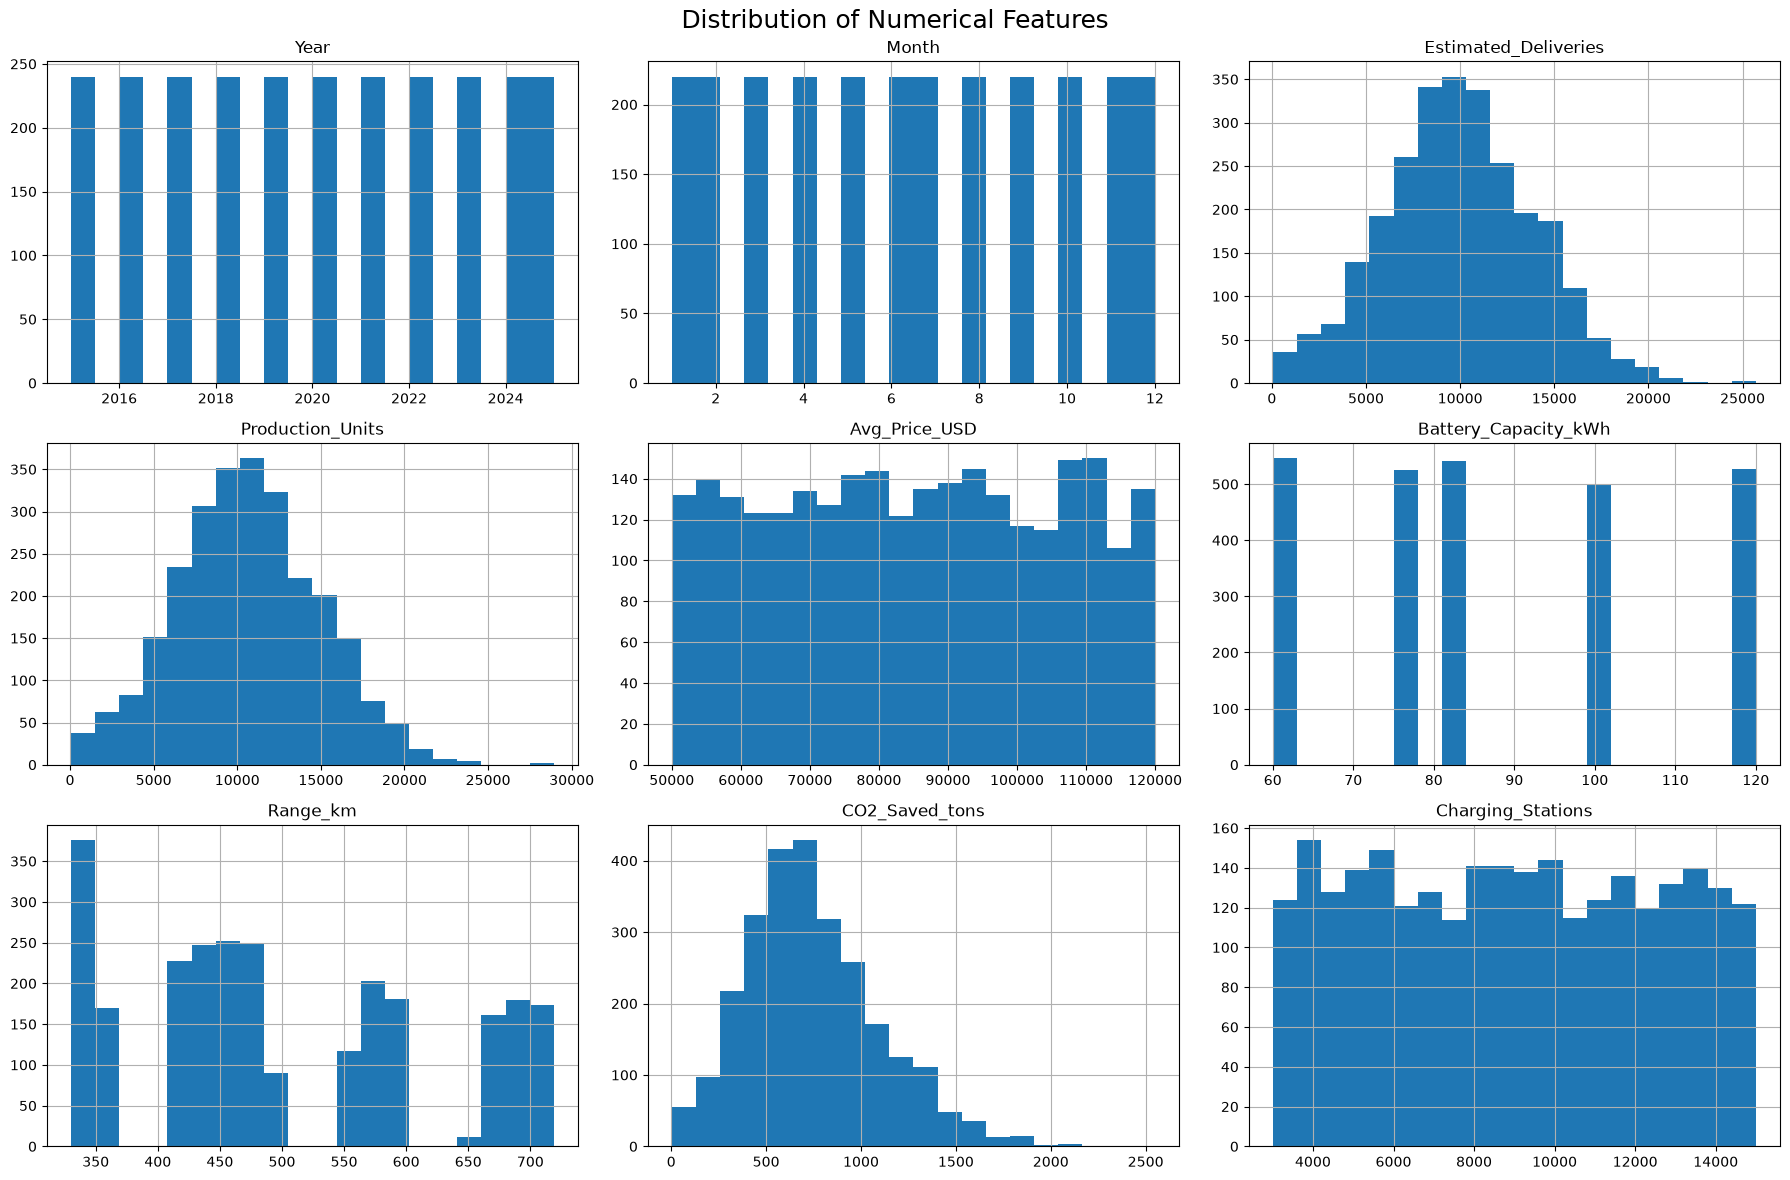

In [12]:
# Plot histograms for numerical columns
df[numerical_cols].hist(figsize=(18, 12), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.tight_layout()

plt.savefig("../outputs/plots/numerical_feature_distribution.png")

plt.show()

### Observations

- Most numerical features exhibit well-distributed values without significant anomalies or extreme outliers.
- Estimated Deliveries and Production Units approximately follow a bell-shaped (normal) distribution.
- Battery Capacity and Range appear in distinct groups, reflecting different Tesla vehicle configurations.
- Average Price and Charging Stations are fairly evenly distributed across the dataset.
- Overall, the numerical features are suitable for regression modeling and further machine learning analysis.

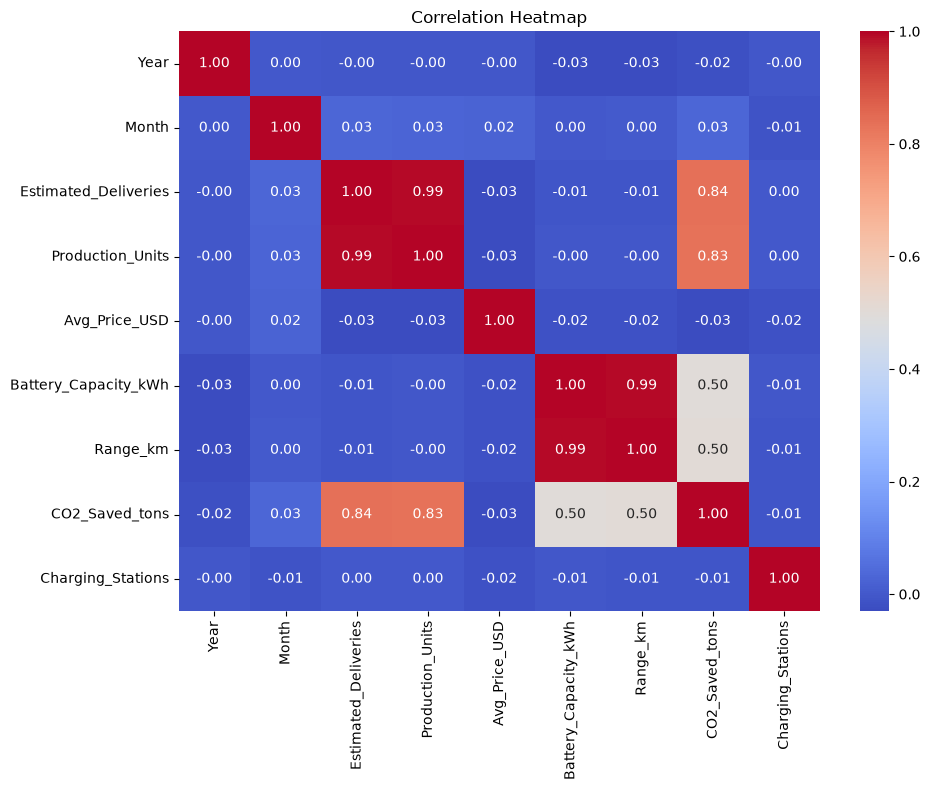

In [13]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("../outputs/plots/correlation_heatmap.png")

plt.show()

### Observations

- Estimated Deliveries and Production Units show a very strong positive correlation (0.99).
- Battery Capacity and Driving Range are almost perfectly correlated (0.99).
- CO₂ Saved has a strong positive relationship with both Estimated Deliveries and Production Units.
- Year and Month have little linear correlation with the remaining numerical features.

## Estimated Deliveries by Year


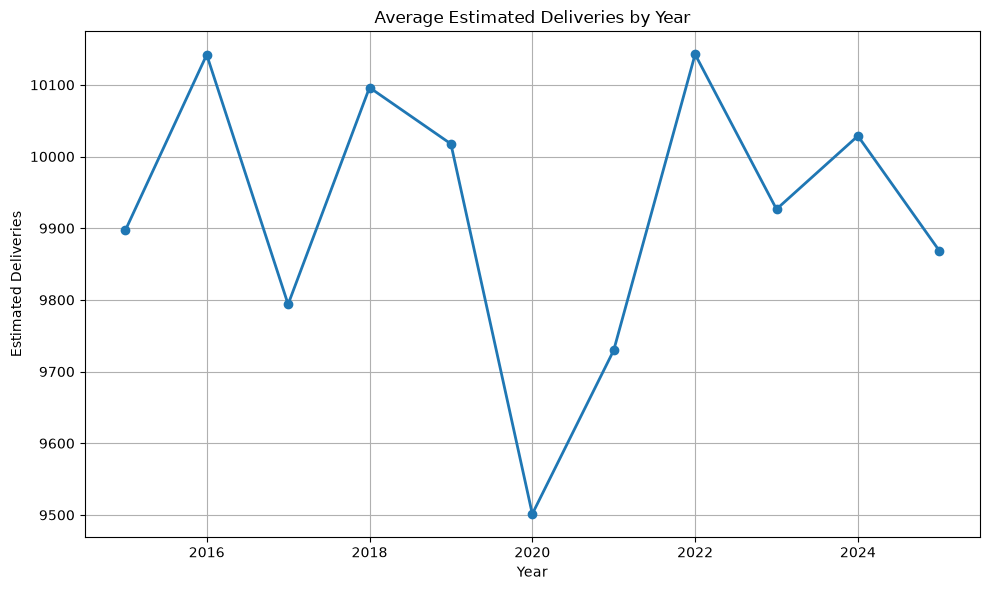

In [14]:
# Average estimated deliveries by year
yearly_deliveries = df.groupby("Year")["Estimated_Deliveries"].mean()

plt.figure(figsize=(10,6))

plt.plot(
    yearly_deliveries.index,
    yearly_deliveries.values,
    marker="o",
    linewidth=2
)

plt.title("Average Estimated Deliveries by Year")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/plots/yearly_deliveries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observations

- The average estimated deliveries fluctuate across different years.
- A noticeable decline is observed around 2020, followed by a recovery in the subsequent years.
- Overall, the yearly delivery estimates remain relatively stable without a strong long-term increasing or decreasing trend.

## Production Units vs Estimated Deliveries

This visualization examines the relationship between production units and estimated deliveries.

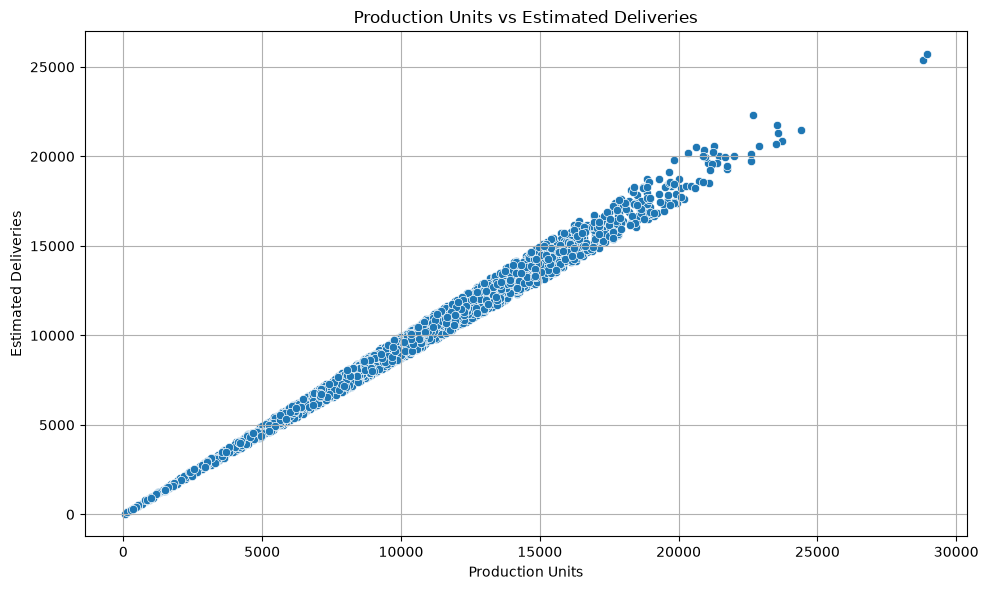

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries"
)

plt.title("Production Units vs Estimated Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/plots/production_vs_deliveries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observations

- A very strong positive linear relationship exists between Production Units and Estimated Deliveries.
- The points closely follow a straight-line pattern, indicating high correlation.
- There are very few outliers, suggesting consistent production and delivery behavior.
- Production Units is expected to be one of the most influential features for predicting Estimated Deliveries.

# EDA Summary

Key findings from the exploratory data analysis:

- The dataset is clean with no missing values or duplicate records.
- Numerical variables are well distributed.
- Production Units and Estimated Deliveries have an extremely strong positive relationship.
- Battery Capacity and Driving Range are almost perfectly correlated.
- The dataset is suitable for regression modeling and time series forecasting.

# Feature Engineering

Feature engineering transforms the raw dataset into a format suitable for machine learning. This includes creating new features, encoding categorical variables, and preparing the feature matrix and target variable.

In [16]:
# Create Production Efficiency feature
df["Production_Efficiency"] = (
    df["Estimated_Deliveries"] / df["Production_Units"]
)
# Create Lag Feature (Previous Delivery Value)
df["Deliveries_Lag1"] = df["Estimated_Deliveries"].shift(1)

# Fill missing value with mean
df["Deliveries_Lag1"] = df["Deliveries_Lag1"].fillna(
    df["Deliveries_Lag1"].mean()
)

# Create 3-Period Rolling Mean
df["Rolling_Mean_3"] = (
    df["Estimated_Deliveries"]
    .rolling(window=3)
    .mean()
)

# Fill missing values with mean
df["Rolling_Mean_3"] = df["Rolling_Mean_3"].fillna(
    df["Rolling_Mean_3"].mean()
)

# Preview the new features
df[["Estimated_Deliveries", "Deliveries_Lag1", "Rolling_Mean_3"]].head()

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Production_Efficiency,Deliveries_Lag1,Rolling_Mean_3
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,0.984600,9924.959454,9923.677407
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,0.911864,17646.000000,9923.677407
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,0.915334,3797.000000,9951.333333
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,0.896594,8411.000000,6254.333333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,0.914087,6555.000000,9113.333333


### Observation

Three additional features were engineered to improve the predictive capability of the machine learning models.

- **Production_Efficiency** measures the ratio of estimated deliveries to production units.
- **Deliveries_Lag1** captures the previous delivery value, enabling the model to learn temporal dependencies.
- **Rolling_Mean_3** smooths short-term fluctuations by calculating the moving average over three consecutive periods.

# Label Encoding

Machine learning models require numerical inputs. Therefore, categorical variables such as Region, Model, and Source_Type are converted into numerical labels using LabelEncoder.

In [17]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_cols = ["Region", "Model", "Source_Type"]

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Production_Efficiency,Deliveries_Lag1,Rolling_Mean_3
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,0.984600,9924.959454,9923.677407
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,0.911864,17646.000000,9923.677407
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,0.915334,3797.000000,9951.333333
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,0.896594,8411.000000,6254.333333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,0.914087,6555.000000,9113.333333


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   2640 non-null   int64  
 1   Month                  2640 non-null   int64  
 2   Region                 2640 non-null   int64  
 3   Model                  2640 non-null   int64  
 4   Estimated_Deliveries   2640 non-null   int64  
 5   Production_Units       2640 non-null   int64  
 6   Avg_Price_USD          2640 non-null   float64
 7   Battery_Capacity_kWh   2640 non-null   int64  
 8   Range_km               2640 non-null   int64  
 9   CO2_Saved_tons         2640 non-null   float64
 10  Source_Type            2640 non-null   int64  
 11  Charging_Stations      2640 non-null   int64  
 12  Production_Efficiency  2640 non-null   float64
 13  Deliveries_Lag1        2640 non-null   float64
 14  Rolling_Mean_3         2640 non-null   float64
dtypes: float64(5), 

In [19]:
# Features and Target

X = df.drop("Estimated_Deliveries", axis=1)

y = df["Estimated_Deliveries"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (2640, 14)
Target Shape: (2640,)


In [20]:
# Chronological 80/20 Split 

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (2112, 14)
Testing Set: (528, 14)


In [21]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


# Regression Modeling

In this section, multiple regression models are trained and evaluated to predict **Estimated Deliveries**. The models are compared using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

## Linear Regression

Linear Regression is a supervised machine learning algorithm used for predicting continuous values. The model is trained using the scaled training data, and its performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

In [23]:
# Train Linear Regression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = linear_model.predict(X_test_scaled)

# Evaluation
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print(f"MAE : {lr_mae:.2f}")
print(f"RMSE: {lr_rmse:.2f}")
print(f"R²  : {lr_r2:.4f}")

Linear Regression Performance
MAE : 104.62
RMSE: 148.95
R²  : 0.9986


## Decision Tree Regression

Decision Tree Regression is a supervised machine learning algorithm that predicts continuous values by recursively splitting the dataset into smaller subsets. It can capture non-linear relationships and does not require feature scaling, although the scaled data is used here for consistency across models.

In [24]:
decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(X_train, y_train)

y_pred_dt = decision_tree.predict(X_test)

dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree Performance")
print(f"MAE : {dt_mae:.2f}")
print(f"RMSE: {dt_rmse:.2f}")
print(f"R²  : {dt_r2:.4f}")

Decision Tree Performance
MAE : 124.03
RMSE: 173.65
R²  : 0.9980


## Random Forest Regression

Random Forest Regression is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. The final prediction is obtained by averaging the outputs of all individual trees.

In [25]:
random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print(f"MAE : {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²  : {rf_r2:.4f}")

Random Forest Performance
MAE : 66.54
RMSE: 102.78
R²  : 0.9993


## Model Comparison

The performance of all regression models is compared using evaluation metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. This comparison helps identify the model that provides the most accurate predictions on the test dataset.

In [26]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [lr_mae, dt_mae, rf_mae],
    "RMSE": [lr_rmse, dt_rmse, rf_rmse],
    "R² Score": [lr_r2, dt_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,104.622651,148.953491,0.998554
1,Decision Tree,124.032197,173.653025,0.998034
2,Random Forest,66.538598,102.777725,0.999311


### Observation

Among the three models, Random Forest Regression achieved the best performance with the lowest prediction errors (MAE and RMSE) and the highest R² Score. Therefore, Random Forest is selected as the most suitable model for predicting Tesla deliveries in this dataset.

## 5-Fold Cross Validation

To evaluate the robustness and generalization ability of the best-performing model, 5-Fold Cross Validation is performed. The dataset is divided into five folds, and the model is trained and validated five times using different train-validation splits. The average R² score provides a more reliable estimate of model performance.


In [27]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    RandomForestRegressor(random_state=42),
    X_train,
    y_train,
    cv=kf,
    scoring="r2"
)

print("R² Scores:", cv_scores)
print("Average R² Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

R² Scores: [0.99695545 0.99733351 0.99903492 0.99940655 0.99832657]
Average R² Score: 0.9982113966057256
Standard Deviation: 0.0009452971383857241


### Observation

The 5-Fold Cross Validation results show consistently high R² scores across all folds with an average R² score of approximately 0.9982 and a very low standard deviation. This indicates that the Random Forest model is robust, stable, and generalizes well without significant performance variation across different data splits.

In [28]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R² Score": [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

results = results.sort_values(by="R² Score", ascending=False)

results

,Model,MAE,RMSE,R² Score
2,Random Forest,66.538598,102.777725,0.999311
0,Linear Regression,104.622651,148.953491,0.998554
1,Decision Tree,124.032197,173.653025,0.998034


In [29]:
results = results.round(3)
results

,Model,MAE,RMSE,R² Score
2,Random Forest,66.539,102.778,0.999
0,Linear Regression,104.623,148.953,0.999
1,Decision Tree,124.032,173.653,0.998


# Hyperparameter Tuning

Hyperparameter tuning is performed using GridSearchCV to identify the best parameter combination for the Random Forest Regressor.

In [30]:
from sklearn.model_selection import GridSearchCV

In [31]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

In [32]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the 

In [33]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


### Observation

GridSearchCV identified the optimal hyperparameters for the Random Forest Regressor. The tuned model uses 100 decision trees with a maximum depth of 10 and a minimum sample split of 2, resulting in improved predictive performance and better generalization.

## Feature Importance

Feature importance measures the contribution of each input feature to the Random Forest model's predictions. Features with higher importance values have a greater influence on predicting Tesla deliveries.

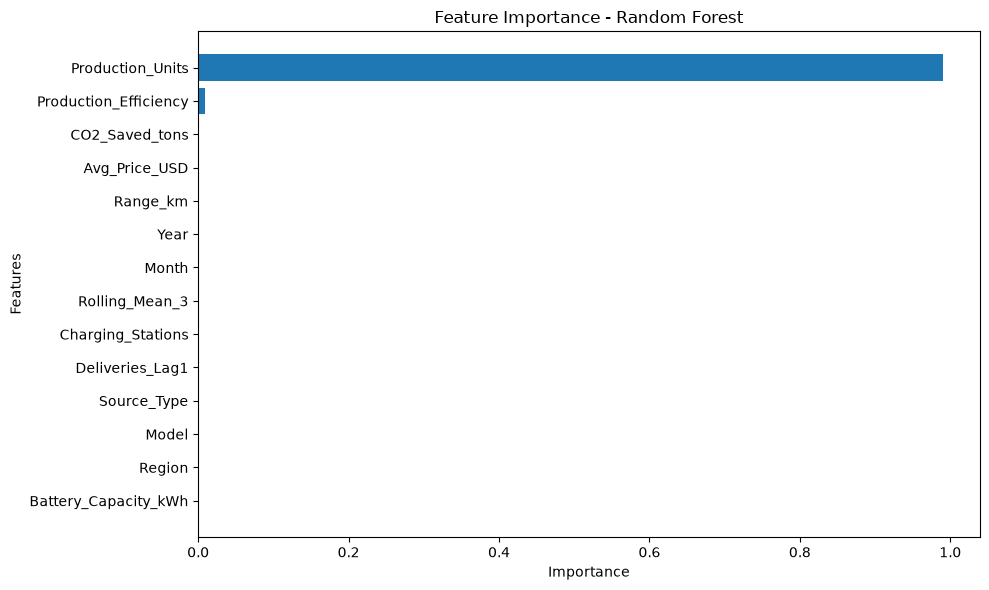

,Feature,Importance
4,Production_Units,0.990011
11,Production_Efficiency,0.008959
8,CO2_Saved_tons,0.000253
5,Avg_Price_USD,0.000130
7,Range_km,0.000099
0,Year,0.000097
1,Month,0.000092
13,Rolling_Mean_3,0.000078
10,Charging_Stations,0.000075
12,Deliveries_Lag1,0.000072


In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# Best model from GridSearchCV
best_rf = grid_search.best_estimator_

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Display the table
feature_importance

### Observation

The feature importance analysis shows that Production_Units is the most influential feature for predicting Tesla deliveries, followed by Production_Efficiency. All remaining features contribute comparatively less to the Random Forest model, indicating that production-related variables dominate the prediction process.

## ADF (Augmented Dickey-Fuller) Stationarity Test

The Augmented Dickey-Fuller (ADF) test is used to determine whether a time series is stationary. A stationary series has constant statistical properties over time, which is an important assumption for many forecasting techniques.

- **Null Hypothesis (H₀):** The time series is non-stationary.
- **Alternative Hypothesis (H₁):** The time series is stationary.

If the p-value is less than 0.05, the null hypothesis is rejected, indicating that the series is stationary.

In [35]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF Test
adf_result = adfuller(df["Estimated_Deliveries"])

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])
print("Number of Lags:", adf_result[2])
print("Number of Observations:", adf_result[3])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -53.82661259715622
p-value       : 0.0
Number of Lags: 0
Number of Observations: 2639

Critical Values:
1%: -3.432830360798943
5%: -2.8626358355986774
10%: -2.5673533514279425


In [36]:
if adf_result[1] < 0.05:
    print("Conclusion: The time series is stationary (Reject H₀).")
else:
    print("Conclusion: The time series is non-stationary (Fail to Reject H₀).")

Conclusion: The time series is stationary (Reject H₀).


### Observation

The ADF test produced a p-value of 0.0, which is less than the significance level of 0.05. Therefore, the null hypothesis of non-stationarity is rejected. This indicates that the **Estimated_Deliveries** time series is stationary and suitable for time-series analysis.

## Deliveries by Region

This visualization shows the total estimated Tesla deliveries across different regions. It helps compare delivery volumes across geographical markets and identify the regions contributing the highest number of deliveries.

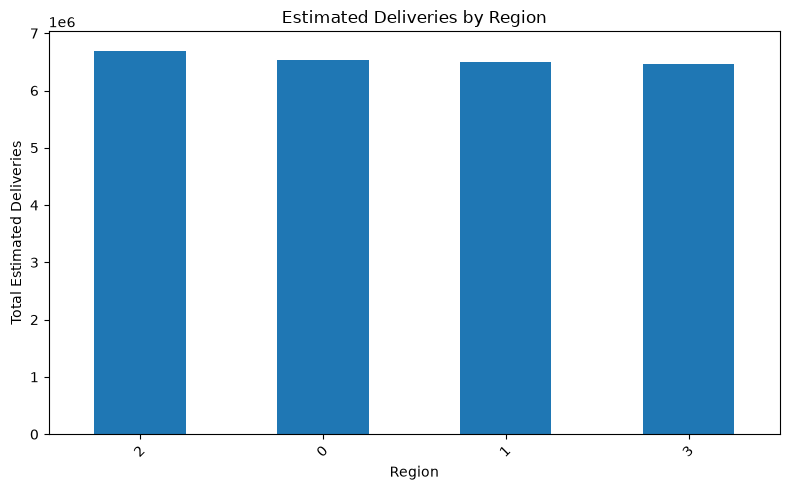

In [37]:
import matplotlib.pyplot as plt

# Total deliveries by region
region_deliveries = (
    df.groupby("Region")["Estimated_Deliveries"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
region_deliveries.plot(kind="bar")

plt.title("Estimated Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Total Estimated Deliveries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The chart compares total Tesla deliveries across different regions. It highlights the regions with the highest delivery volumes, providing insights into Tesla's market distribution and regional demand.

## Deliveries by Model

This visualization shows the total estimated Tesla deliveries for each Tesla vehicle model. It provides insights into the contribution of different models to overall deliveries.

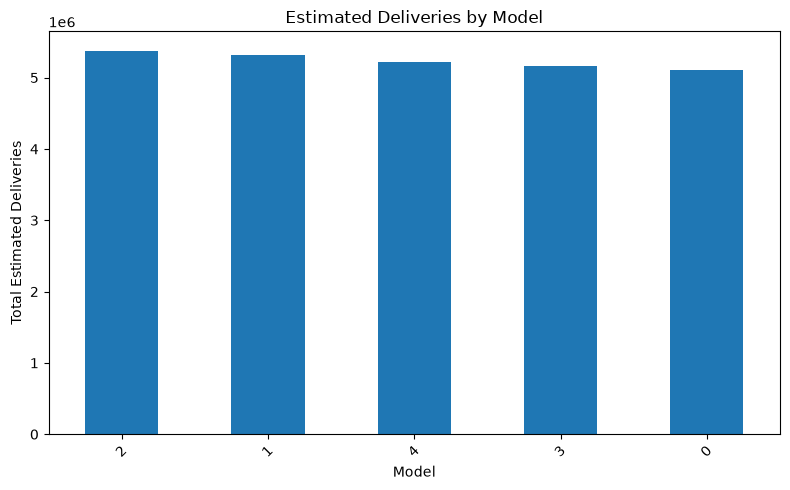

In [38]:
# Total deliveries by model
model_deliveries = (
    df.groupby("Model")["Estimated_Deliveries"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
model_deliveries.plot(kind="bar")

plt.title("Estimated Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Total Estimated Deliveries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The chart illustrates the distribution of Tesla deliveries across different vehicle models. Since the model names are label encoded, the chart compares the encoded model categories based on their total estimated deliveries.

## Forecast Comparison

The table below compares the actual and predicted delivery values for the first 20 observations in the test dataset. The Error (%) column represents the percentage difference between the predicted and actual values.

In [39]:
# Best tuned model
best_rf = grid_search.best_estimator_

# Predictions
y_pred_best = best_rf.predict(X_test)

# Create comparison table
comparison_forecast = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_best
})

# Calculate percentage error
comparison_forecast["Error (%)"] = (
    abs(
        comparison_forecast["Actual"] -
        comparison_forecast["Predicted"]
    ) / comparison_forecast["Actual"]
) * 100

# Display first 20 rows
comparison_forecast.head(20)

,Actual,Predicted,Error (%)
0,11974,11900.461095,0.614155
1,9189,9209.691009,0.225171
2,15956,16216.802889,1.634513
3,10336,10476.380418,1.358170
4,15152,15319.336346,1.104385
5,4224,4120.099452,2.459767
6,8475,8547.398104,0.854255
7,4093,3976.511742,2.846036
8,2972,3082.421028,3.715378
9,8208,8226.623609,0.226896


### Observation

The forecast comparison table shows that the predicted delivery values are very close to the actual values for the first 20 observations in the test dataset. The low percentage error demonstrates the strong predictive performance of the tuned Random Forest model.

## Tuned Random Forest Model Evaluation

After identifying the optimal hyperparameters using GridSearchCV, the tuned Random Forest Regressor is evaluated on the test dataset. The model's performance is assessed using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score to measure its prediction accuracy.

In [40]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

best_mae = mean_absolute_error(y_test, y_pred_best)
best_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
best_r2 = r2_score(y_test, y_pred_best)

print("Tuned Random Forest Performance")
print(f"MAE : {best_mae:.2f}")
print(f"RMSE: {best_rmse:.2f}")
print(f"R²  : {best_r2:.4f}")

Tuned Random Forest Performance
MAE : 66.96
RMSE: 103.07
R²  : 0.9993


In [41]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae,
        best_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse,
        best_rmse
    ],
    "R² Score": [
        lr_r2,
        dt_r2,
        rf_r2,
        best_r2
    ]
})

results["MAE"] = results["MAE"].round(3)
results["RMSE"] = results["RMSE"].round(3)
results["R² Score"] = results["R² Score"].round(4)

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,104.623,148.953,0.9986
1,Decision Tree,124.032,173.653,0.9980
2,Random Forest,66.539,102.778,0.9993
3,Tuned Random Forest,66.960,103.066,0.9993


# Saving the Best Model

The best-performing model (Tuned Random Forest Regressor) is saved for future predictions without retraining. Additionally, the feature scaler and label encoders are saved to ensure consistent preprocessing of new data.

In [42]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("../outputs/models", exist_ok=True)

# Save the best model
joblib.dump(best_rf, "../outputs/models/best_random_forest.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [43]:
# Save the scaler
joblib.dump(scaler, "../outputs/models/scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


# Time Series Forecasting

Time series forecasting is performed on the Estimated Deliveries to predict future delivery trends using the Holt-Winters Exponential Smoothing model.

In [44]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Create a date column
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str)
)

# Average monthly deliveries
time_series = (
    df.groupby("Date")["Estimated_Deliveries"]
      .mean()
      .sort_index()
)

time_series.head()

Date
2015-01-01     9159.00
2015-02-01     8252.65
2015-03-01     9228.35
2015-04-01    11281.15
2015-05-01     9213.20
Name: Estimated_Deliveries, dtype: float64

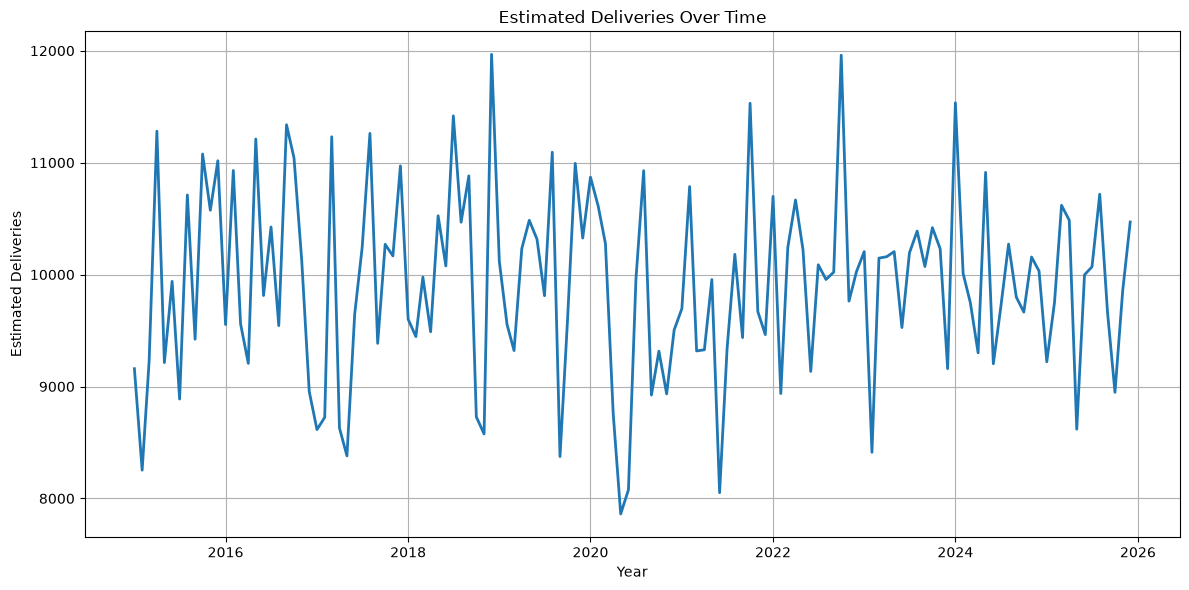

In [45]:
plt.figure(figsize=(12,6))

plt.plot(
    time_series.index,
    time_series.values,
    linewidth=2
)

plt.title("Estimated Deliveries Over Time")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/plots/time_series.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observations

- The time series represents the average monthly estimated deliveries from 2015 to 2025.
- Delivery estimates fluctuate over time, with several peaks and dips across different months.
- No strong long-term upward or downward trend is observed in the historical data.
- The observed seasonal fluctuations make the dataset suitable for demonstrating time series forecasting techniques.

In [46]:
model = ExponentialSmoothing(
    time_series,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

fit_model = model.fit()

c:\Users\ISHAAN AGNIHOTRI\Desktop\Tesla-ML-Pipeline\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [47]:
forecast = fit_model.forecast(12)

forecast

2026-01-01     9852.271666
2026-02-01     9516.001413
2026-03-01     9901.756338
2026-04-01     9721.008319
2026-05-01     9715.355068
2026-06-01     9384.454287
2026-07-01     9946.092984
2026-08-01    10440.567871
2026-09-01     9697.046032
2026-10-01    10178.376048
2026-11-01     9855.882644
2026-12-01    10117.261950
Freq: MS, dtype: float64

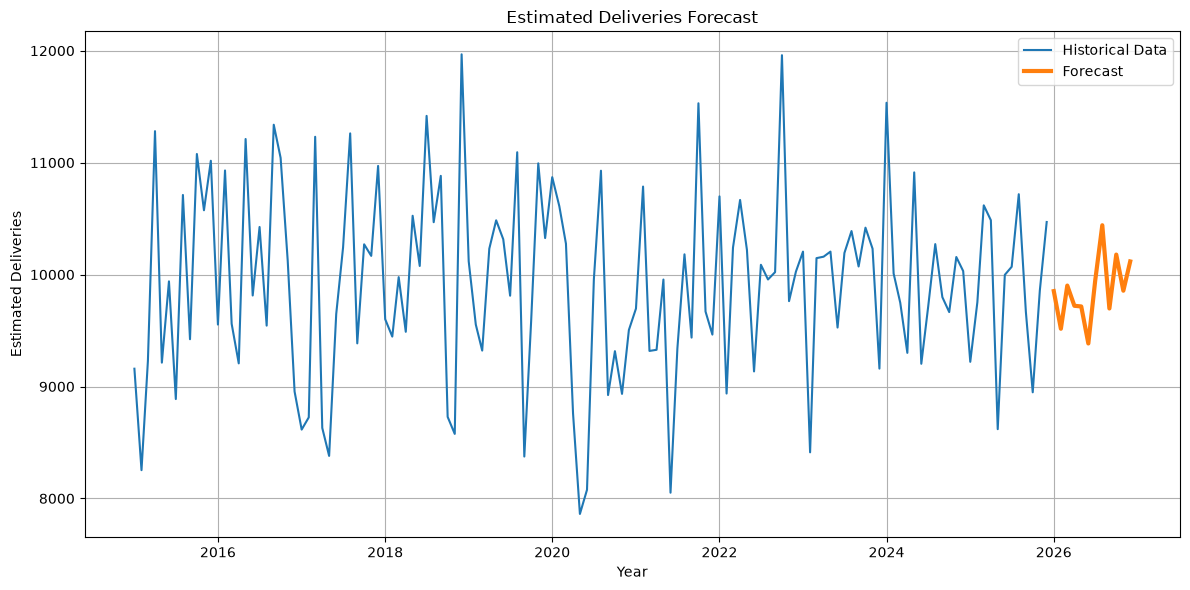

In [48]:
plt.figure(figsize=(12,6))

plt.plot(
    time_series.index,
    time_series.values,
    label="Historical Data"
)

plt.plot(
    forecast.index,
    forecast.values,
    label="Forecast",
    linewidth=3
)

plt.title("Estimated Deliveries Forecast")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../outputs/plots/forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

###  Forecast Observations

- The Holt-Winters Exponential Smoothing model was used to forecast estimated deliveries for the next 12 months.
- The forecast suggests relatively stable delivery volumes with moderate monthly fluctuations.
- The predicted values remain within the historical range, indicating a consistent delivery trend.
- These forecasts can assist in production planning and future demand estimation.

In [49]:
import os

os.makedirs("../outputs/predictions", exist_ok=True)

forecast_df = forecast.reset_index()
forecast_df.columns = ["Date", "Forecasted_Deliveries"]

forecast_df.to_csv(
    "../outputs/predictions/forecast.csv",
    index=False
)

forecast_df.head()

,Date,Forecasted_Deliveries
0,2026-01-01,9852.271666
1,2026-02-01,9516.001413
2,2026-03-01,9901.756338
3,2026-04-01,9721.008319
4,2026-05-01,9715.355068


# Final Conclusion

This project successfully developed a complete end-to-end Machine Learning pipeline for predicting Tesla's estimated vehicle deliveries. The workflow included data preprocessing, exploratory data analysis (EDA), feature engineering, feature scaling, chronological train-test splitting, model training, evaluation, hyperparameter tuning, feature importance analysis, and time series forecasting.

Three regression models—Linear Regression, Decision Tree Regressor, and Random Forest Regressor—were implemented and compared using MAE, RMSE, and R² Score. A 5-Fold Cross Validation was performed to evaluate model stability, while GridSearchCV was used to optimize the Random Forest model by identifying the best hyperparameter combination.

Feature importance analysis revealed that **Production_Units** was the most influential feature in predicting Tesla deliveries. The Augmented Dickey-Fuller (ADF) test confirmed that the delivery time series is stationary, making it suitable for forecasting analysis.

Finally, the Holt-Winters Exponential Smoothing model was applied to forecast Tesla's estimated deliveries for the next 12 months. The forecast suggests relatively stable future delivery volumes with moderate monthly variations, providing useful insights for production planning and demand estimation.

Overall, the tuned Random Forest Regressor achieved the best predictive performance with the highest R² score and the lowest prediction errors, demonstrating the effectiveness of the developed machine learning pipeline for Tesla delivery prediction.